# **TTI109 - Estatística**
# **Laboratório 05 - Estatística Descritiva 4**
# **Visualização de Dados**

Nessa aula vamos aprender a construir:

- Histograma
   - Frequência Absoluta
   - Frequência Relativa
- Polígono de Frequência
   - Frequência Absoluta
   - Frequência Relativa
- Ogiva ou Frequência Acumulada
- Pareto
- Setorial (circular) ou Pizza
- Dados Emparelhados
   - Dispersão
   - Séries Temporais
- Boxplot

# **Exercício: Análise de Vendas em uma Loja de Eletrônicos**

Uma loja de eletrônicos acompanhou suas vendas diárias ao longo de 30 dias. Além disso, a loja registrou o número de produtos vendidos por categoria (TVs, laptops, celulares, tablets) e os preços correspondentes. O objetivo é utilizar esses dados para criar diversos gráficos que permitam uma análise completa das vendas.

### **Dados Fornecidos**

**Vendas Diárias (número de unidades vendidas por dia durante 30 dias):**

```
[12, 15, 14, 10, 12, 16, 18, 17, 14, 19, 20, 22, 21, 15, 14, 13, 16, 15, 12, 10, 9, 11, 13, 17, 18, 19, 20, 21, 22, 23]
```

**Vendas por Categoria (número de unidades vendidas e preços por categoria):**

- TVs: 60 unidades, preço médio (em Reais) 2.000,00
- Laptops: 80 unidades, preço médio (em Reais) 3.500,00
- Celulares: 200 unidades, preço médio (em Reais) 1.200,00
- Tablets: 50 unidades, preço médio (em Reais) 1.800,00
- Datas de Vendas (para séries temporais): Dias 1 a 30 do mês

**Contrua os Gráficos:**

- **Histograma**
  - **Frequência:** Distribua as vendas diárias em intervalos (por exemplo, 5 intervalos) e crie um histograma para mostrar a frequência das vendas.
  - **Frequência Relativa:** Construa o mesmo histograma, mas com a frequência relativa (proporção das vendas).
- **Polígono de Frequência**
  - **Frequência:** Construa um polígono de frequência conectando os pontos médios das barras do histograma de frequência.
  - **Frequência Relativa:** Construa um polígono de frequência relativo conectando os pontos médios das barras do histograma de frequência relativa.
- **Ogiva ou Frequência Acumulada**
  - Construa uma ogiva utilizando as vendas diárias para mostrar a frequência acumulada.
- **Gráfico de Pareto**
  - Com base nas vendas por categoria, crie um gráfico de Pareto mostrando as unidades vendidas por categoria em ordem decrescente e a linha de frequência acumulada.
- **Gráfico Setorial (Pizza)**
  - Construa um gráfico de pizza para mostrar a participação de cada categoria no total de unidades vendidas.
- **Dados Emparelhados**
  - **Dispersão:** Relacione o número de unidades vendidas com o preço médio dos produtos e construa um gráfico de dispersão.
  - **Séries Temporais:** Construa um gráfico de linhas para mostrar as vendas ao longo dos 30 dias.
- **Boxplot**
  - Construa um boxplot das vendas diárias para analisar a distribuição, mediana e possíveis outliers.

### **Criação dos DafaFrames com os dados fornecidos**

In [7]:
# Criação dos DataFrames com os dados fornecidos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.stats import cumfreq

vendas_diarias = [12, 15, 14, 10, 12, 16, 18, 17, 14, 19, 20, 22, 21, 15, 14, 13, 16, 15, 12, 10, 9, 11, 13, 17, 18, 19, 20, 21, 22, 23]
vendas = pd.DataFrame({'Vendas Diarias' : vendas_diarias})

#criar DataFrame com vendas por categoria
categorias = ['Tv', 'Laptops', 'Celulares', 'Tablets']
unidades_vendidas = [60, 80, 200, 50]
vendas_medios = [2000, 3500, 1200, 1800]
vendas_categoria = pd.DataFrame({'Categoria': categorias, 'Unidades Vendidas': unidades_vendidas, 'Vendas Médias': vendas_medios})

display(vendas)
display(vendas_categoria)

print(vendas.describe())



,Vendas Diarias
0,12
1,15
2,14
3,10
4,12
5,16
6,18
7,17
8,14
9,19


,Categoria,Unidades Vendidas,Vendas Médias
0,Tv,60,2000
1,Laptops,80,3500
2,Celulares,200,1200
3,Tablets,50,1800


       Vendas Diarias
count       30.000000
mean        15.933333
std          3.973475
min          9.000000
25%         13.000000
50%         15.500000
75%         19.000000
max         23.000000


### **Criando a tabela de frequências**

In [17]:
#Criando tabela de frequencia das vendas
# Usarenos 5 classes (bins)
n_classes = 5
# Valores máximo e mínimo
v_max = vendas['Vendas Diarias'].max()
v_min = vendas['Vendas Diarias'].min()
# Amplitude e limites das classes de forma manual
v_max = vendas['Vendas Diarias'].max()
amplitude = round((v_max - v_min) / n_classes)
# Cria uma lista de limites das classes. A 'amplitude' define a largura de cada classe
# 0 '+2' assegura que o valor máximo seja incluído na última classe
classes = np.arange (v_min, v_max + 2, amplitude)
# Cria a tabela de frequências
tabela_frequencias = vendas['Vendas Diarias'].value_counts(bins=n_classes).sort_index()
tabela_frequencias = tabela_frequencias.reset_index()
tabela_frequencias.columns = ['Classe', 'Frequência']
#Variáveis
# Atualiza a tabela de frequências
tabela_frequencias['Classe'] = tabela_frequencias['Frequência'].index
tabela_frequencias['Pontos médios'] = (classes[:-1] + classes[1:]) / 2
tabela_frequencias['Frequência relativa'] = tabela_frequencias['Frequência'].values / len(vendas['Vendas Diarias'])

# Frequência acumulada
tabela_frequencias['Frequência acumulada'] = tabela_frequencias['Frequência'].cumsum()

#imprime a tabela
display(tabela_frequencias)


,Classe,Frequência,Pontos médios,Frequência relativa,Frequência acumulada
0,0,4,10.5,0.133333,4
1,1,8,13.5,0.266667,12
2,2,7,16.5,0.233333,19
3,3,6,19.5,0.200000,25
4,4,5,22.5,0.166667,30


### **1 - Histograma  Frequência**

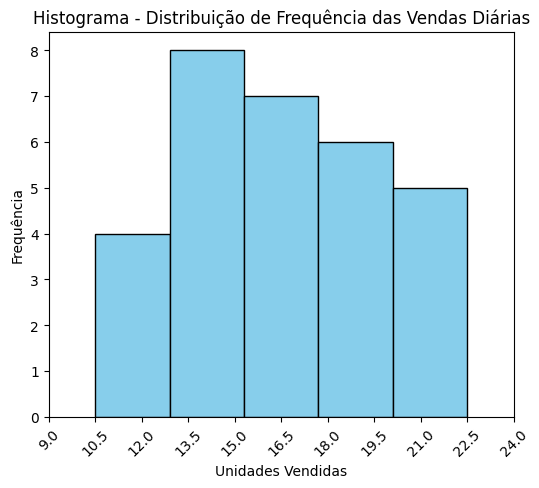

In [18]:
# 1. Histograma - Frequência
# Histograma Frequencia 
plt.figure(figsize=(6,5))
plt.hist(x=tabela_frequencias['Pontos médios'], bins=n_classes, weights=tabela_frequencias['Frequência'], color='skyblue', edgecolor='black')
#Vendas ['Vendas Diarias'].plot.hist(bins=n_classes, color='skyblue', edgecolor='black')
plt.title('Histograma - Distribuição de Frequência das Vendas Diárias')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Frequência')

# Usaos lomites das classes e os pontosmedios como major ticket no eixo X. Rotacionamos o texto em 45 graus
plt.xticks(np.concatenate([classes, tabela_frequencias['Pontos médios']]), rotation=45)

#mostra o gráfico
plt.show()

### **2. Histograma - Frequência Relativa**

In [ ]:
# 2. Histograma - Frequência Relativa



### **3. Polígono de Frequência - Frequência**

Ponto medio ficticio á esqerda = 7.5
Ponto medio ficticio á direita = 25.5


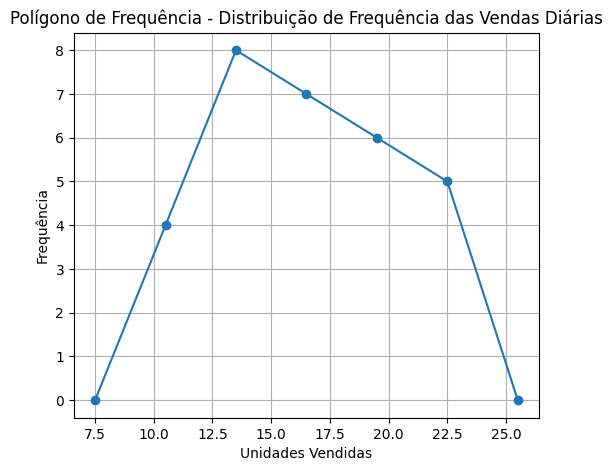

In [19]:
# 3. Polígono de Frequência - Frequência

# Calculos dos medios ficticios 
fic_esq = [tabela_frequencias['Pontos médios'][0] - amplitude]
print(f'Ponto medio ficticio á esqerda = {fic_esq[0]}')
fic_dir = [tabela_frequencias['Pontos médios'].iloc[-1] + amplitude]
print(f'Ponto medio ficticio á direita = {fic_dir[0]}')

# COnstrução dos dados com inserção dos pontos médios ficticios
x_data = np.concatenate([fic_esq, tabela_frequencias['Pontos médios'], fic_dir])
y_data = np.concatenate([[0], tabela_frequencias['Frequência'].values, [0]])

# Plot do gráfico
plt.figure(figsize=(6,5))
plt.plot(x_data, y_data, marker='o')
plt.title('Polígono de Frequência - Distribuição de Frequência das Vendas Diárias')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Frequência')

# Mostra o grafico 
plt.grid()

### **4. Polígono de Frequência - Frequência Relativa**

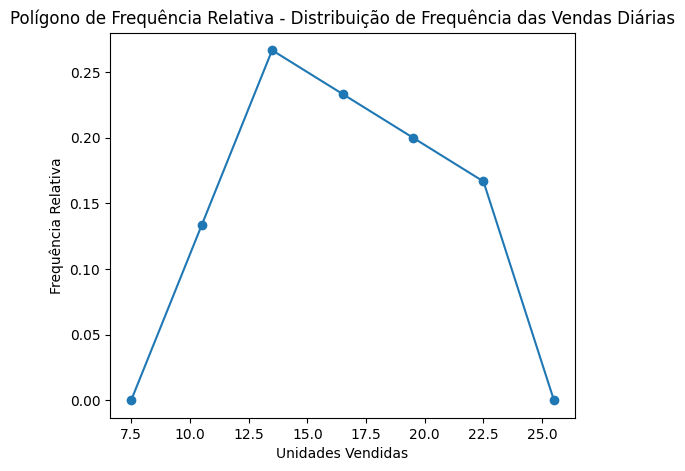

In [25]:
# 4. Polígono de Frequência - Frequência Relativa

# Calculo dos Pontos Medios ficticios
#Construção dos dados com inserção dos pontos médios ficticios
y_data = np.concatenate([[0], tabela_frequencias['Frequência relativa'], [0]])


# Plot do gráfico
plt.figure(figsize=(6,5))
plt.plot(x_data, y_data, marker='o')
plt.title('Polígono de Frequência Relativa - Distribuição de Frequência das Vendas Diárias')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Frequência Relativa')

# MOstra o gráfico
plt.show()

### **5. Ogiva (Frequência Acumulada)**

In [ ]:
# 5. Ogiva (Frequência Acumulada)


### **6. Gráfico de Pareto**

In [ ]:
# 6. Gráfico de Pareto


### **7. Gráfico Setorial (Pizza)**

In [ ]:
# 7. Gráfico Setorial (Pizza)


### **8. Dados Emparelhados - Dispersão**

In [ ]:
# 8. Dados Emparelhados - Dispersão


### **9. Dados Emparelhados - Séries Temporais**

In [ ]:
# 9. Dados Emparelhados - Séries Temporais


### **10. Boxplot**

In [ ]:
# 10. Boxplot


# **EXTRA: Análise dos quartis de um painel de dados**

Um diagrama boxplot (ou caixa-e-bigode) é uma ferramenta de análise exploratória que destaca características importantes de um conjunto de dados.
Os dados utilizados no exercício anterior de uma Loja de Eletrônicos são simples, pois o intuitofoi deé aprender a utilizara ferramenta Python.
 Para expandir o uso de boxplots, vamos importar um grande conjunto de dados levantados a partir das gorjetas dadas por clientes de um restaurante.

O conjunto de dados possui os seguintes parâmetros:
- **valor_total:** valor total gasto no restaurante
- **gorjeta:** valor da gorjeta
- **sexo:** como o cliente pagante se identificou
- **fumante:** cliente fumante ou não
- **dia:** dia do atendimento
- **hora:** horário do atendimento
- **tamanho:** número de pessoas à mesa.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

# Importação do conjunto de dados
gorjetas = pd.read_csv("gorjetas.csv")
print('5 primeiras linhas do conjunto de dados:')
display(gorjetas.head())

# Determinação dos quartis
quartis = gorjetas.quantile([0.25, 0.5, 0.75], axis=0,
                            interpolation='linear', numeric_only=True)
print('Tabela com os quartis para cada coluna numérica:')
display(quartis)

# Percentis customizados
percentis = gorjetas.quantile([0.1, 0.3, 0.8], axis=0,
                              interpolation='linear', numeric_only=True)
print('Tabela com percentis customizados:')
display(percentis)

# Análise exploratória inicial
print('Análise exploraória:')
gorjetas.describe()

### Boxplot - Painéis de dados

O uso do método boxplot() tem seu total potencial realizado quando os dados são um DataFrame.

Vamos checar a distribuição do valor das contas por dia de funcionamento do restaurante.

In [ ]:
gorjetas.boxplot(by='dia', column=['valor_total'], color='red', showmeans=True, figsize=(6, 5))

# Título
plt.title('Distribuição do valor das contas')
plt.ylabel('Valor')
plt.suptitle('')

# Mostra o gráfico
plt.show()

### Agora, vamos examinar a distribuição das gorjetas por dia de funcionamento do restaurante

In [ ]:
gorjetas.boxplot(by='dia', column=['gorjeta'], color='red', showmeans=True, figsize=(6, 5))

# Título
plt.title('Distribuição do valor das gosjetas')
plt.ylabel('Valor')
plt.suptitle('')

# Mostra o gráfico
plt.show()

### Distribuição das gorjetas agrupada por período de funcionamento

In [ ]:
gorjetas.boxplot(by='hora', column=['gorjeta'], color='red', showmeans=True, figsize=(6, 5))

# Título
plt.title('Distribuição do valor das gosjetas')
plt.ylabel('Valor')
plt.suptitle('')

# Mostra o gráfico
plt.show()

### Também é possível agrupar a distribuição de gorjetas usando dois ou mais fatores.

Aqui, vamos agrupar por dia de funcionamento e como o cliente pagante se identificou

In [ ]:
gorjetas.boxplot(by=['dia', 'sexo'], column=['gorjeta'], color='red', showmeans=True, figsize=(12, 5))

# Título
plt.title('Distribuição do valor das gosjetas')
plt.ylabel('Valor')
plt.suptitle('')

# Rotacionar os textos do eixo x em 45 graus
plt.xticks(rotation=45)

# Mostra o gráfico
plt.show()